# Lab 6 – Filtering in the Frequency Domain

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

## Task 1: Laplacian in the Frequency Domain (Cameraman)

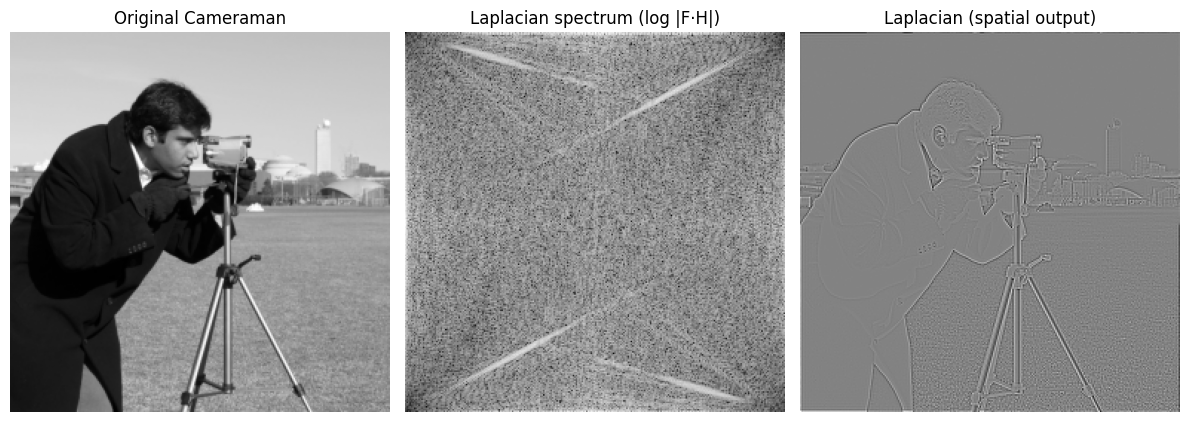

In [3]:
# Load cameraman image (grayscale)
image = data.camera()
image = resize(image, (256, 256))

M, N = image.shape

# Frequency grid (ordering matches np.fft.fft2)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Laplacian transfer function in the frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u ** 2 + v ** 2)

F = np.fft.fft2(image)
F_lap = F * laplacian_filter
laplacian_image = np.fft.ifft2(F_lap).real

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Cameraman")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap="gray")
plt.title("Laplacian spectrum (log |F·H|)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap="gray")
plt.title("Laplacian (spatial output)")
plt.axis("off")

plt.tight_layout()
plt.show()

---
## Assessment

### Assessment Task 1: Sobel filters in the frequency domain

<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/d9/df2zrtl57q97j2nn1j6rw6bc0000gn/T/ipykernel_35306/415060107.py:52: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 2].set_title("Gradient magnitude $\sqrt{G_x^2+G_y^2}$")


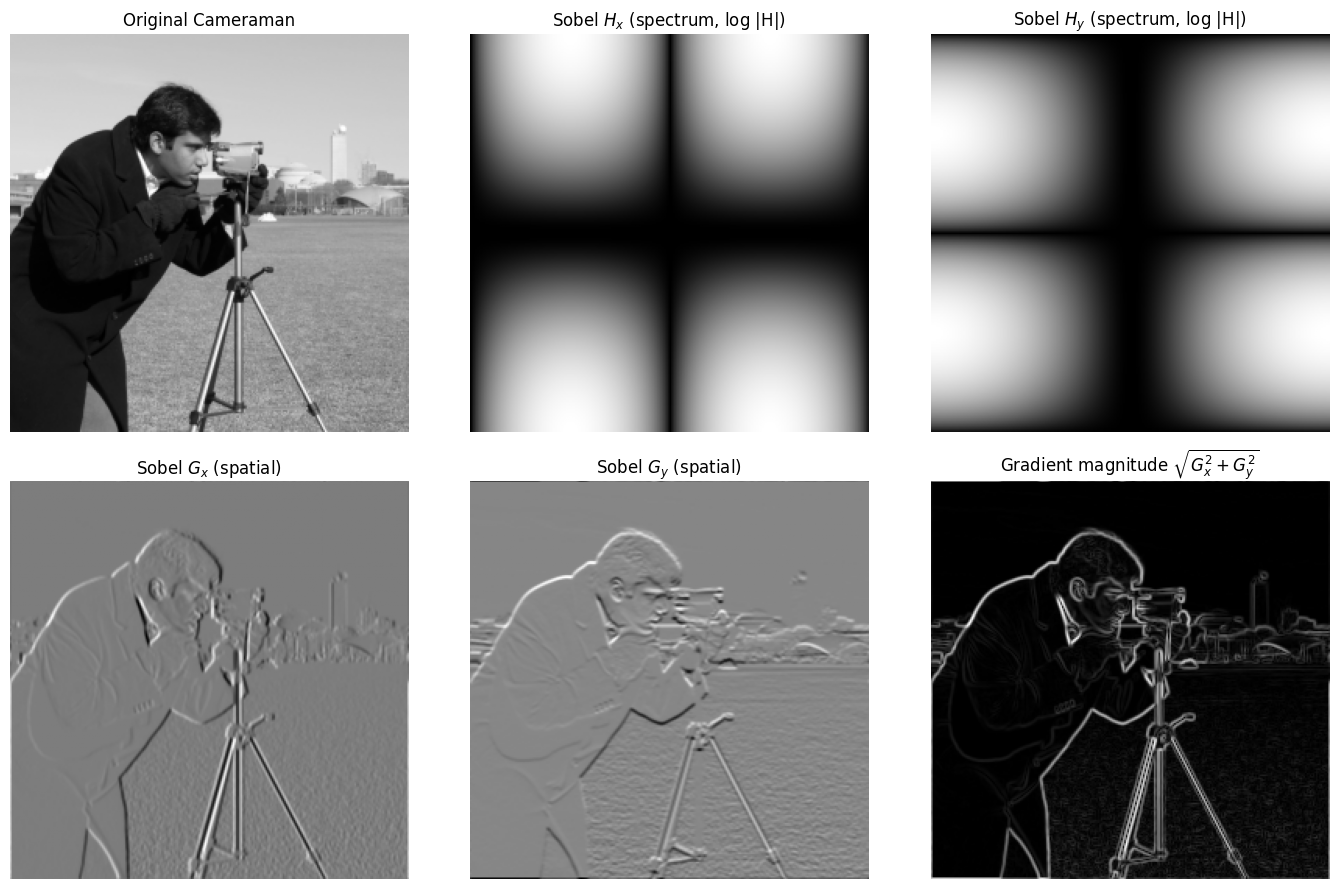

In [4]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)


def center_embed_kernel(kernel, shape):
    """Embed kernel at image center, then FFT with origin at top-left (ifftshift)."""
    padded = np.zeros(shape, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh // 2 : cy - kh // 2 + kh, cx - kw // 2 : cx - kw // 2 + kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded))


image = data.camera()
image = resize(image, (256, 256))
M, N = image.shape

F = np.fft.fft2(image)
H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

G_x = F * H_x
G_y = F * H_y
sobel_x_spatial = np.fft.ifft2(G_x).real
sobel_y_spatial = np.fft.ifft2(G_y).real
gradient_mag = np.sqrt(sobel_x_spatial ** 2 + sobel_y_spatial ** 2)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original Cameraman")
axes[0, 0].axis("off")

axes[0, 1].imshow(np.log(1 + np.abs(H_x)), cmap="gray")
axes[0, 1].set_title("Sobel $H_x$ (spectrum, log |H|)")
axes[0, 1].axis("off")

axes[0, 2].imshow(np.log(1 + np.abs(H_y)), cmap="gray")
axes[0, 2].set_title("Sobel $H_y$ (spectrum, log |H|)")
axes[0, 2].axis("off")

axes[1, 0].imshow(sobel_x_spatial, cmap="gray")
axes[1, 0].set_title("Sobel $G_x$ (spatial)")
axes[1, 0].axis("off")

axes[1, 1].imshow(sobel_y_spatial, cmap="gray")
axes[1, 1].set_title("Sobel $G_y$ (spatial)")
axes[1, 1].axis("off")

axes[1, 2].imshow(gradient_mag, cmap="gray")
axes[1, 2].set_title("Gradient magnitude $\sqrt{G_x^2+G_y^2}$")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()